# Analysis


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("train.csv")
df.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
768,769,0,3,"Moran, Mr. Daniel J",male,NaN,1,0,371110,24.1500,NaN,Q
566,567,0,3,"Stoytcheff, Mr. Ilia",male,19.0,0,0,349205,7.8958,NaN,S
747,748,1,2,"Sinkkonen, Miss. Anna",female,30.0,0,0,250648,13.0000,NaN,S
132,133,0,3,"Robins, Mrs. Alexander A (Grace Charity Laury)",female,47.0,1,0,A/5. 3337,14.5000,NaN,S
686,687,0,3,"Panula, Mr. Jaako Arnold",male,14.0,4,1,3101295,39.6875,NaN,S
430,431,1,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,0,0,110564,26.5500,C52,S
667,668,0,3,"Rommetvedt, Mr. Knud Paust",male,NaN,0,0,312993,7.7750,NaN,S


## Dealing with Categorical data

### 1. Countplot

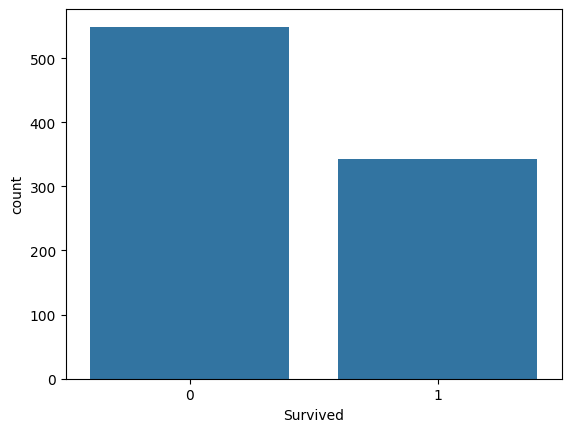

In [3]:
# Recommended way
# sns.countplot(data=df, x='Survived',hue='Sex')
sns.countplot(data=df, x='Survived')
plt.show()

<Axes: ylabel='Survived'>

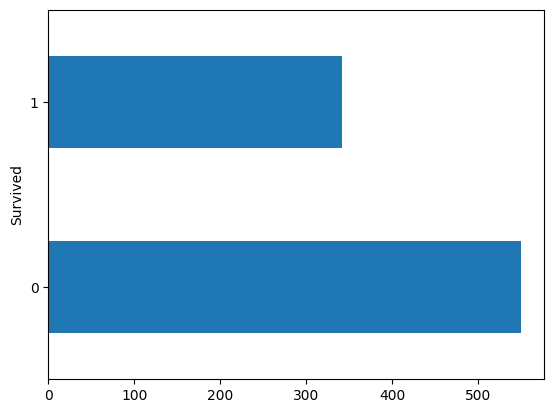

In [17]:
df['Survived'].value_counts().plot(kind='barh')

In [4]:
# df['Survived'].value_counts().plot(kind='barh')
df['Survived'].value_counts()
# df.groupby('Sex')['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [24]:
data = df.groupby('Sex')['Survived'].value_counts()
print(type(data))
print(data)

female_survived = data['female'][1]
female_dead = data['female'][0]

female_percentage = female_survived / (female_survived + female_dead) * 100

print(female_percentage)


<class 'pandas.Series'>
Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64
74.20382165605095


In [26]:
data = df.groupby('Sex')['Survived'].value_counts(normalize=True) * 100
# Don't give me counts. Give me proportions (or percentages)
print(data)

Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64


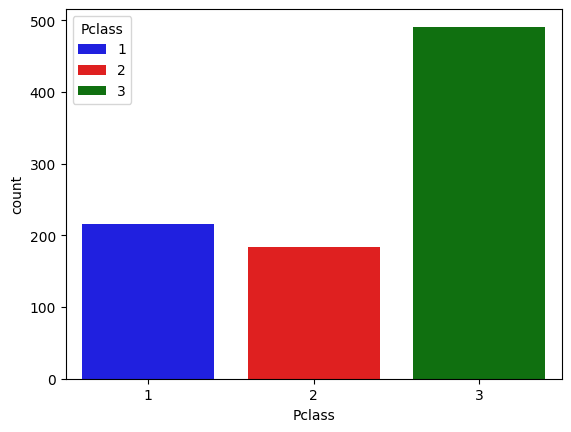

In [28]:
sns.countplot(
    data=df,
    x='Pclass',
    hue='Pclass',
    palette=['blue', 'red', 'green'],
    legend=True
)
plt.show()

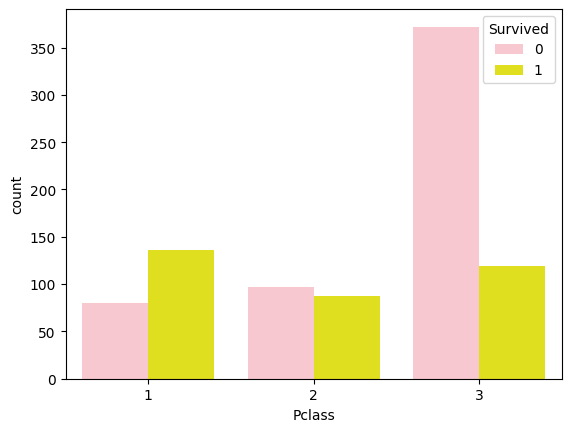

In [31]:
sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived',
    palette=['pink','yellow'],
    legend=True
)
plt.show()

### 2. Pie Chart

<Axes: >

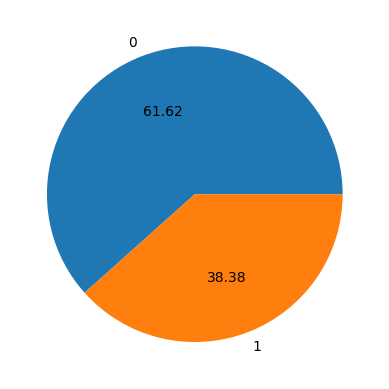

In [32]:
df['Survived'].value_counts().plot(kind='pie',autopct = '%.2f')

<Axes: >

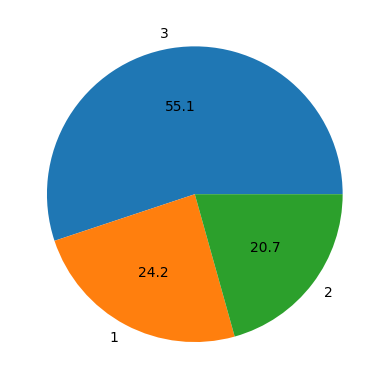

In [8]:
df['Pclass'].value_counts().plot(kind='pie',autopct = '%.1f')

<Axes: >

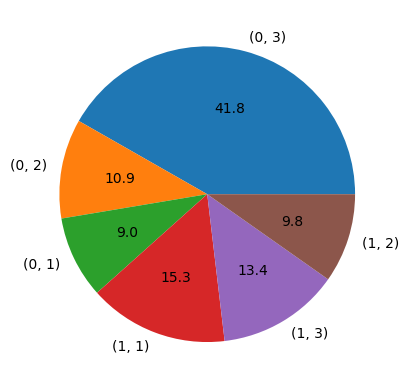

In [9]:
df.groupby('Survived')['Pclass'].value_counts().plot(kind='pie',autopct = '%.1f')


## Numerical Data

### 1. Histogram

In [33]:
df.shape

(891, 12)

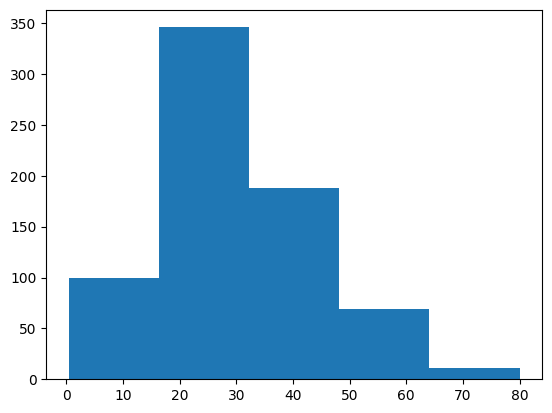

In [10]:
plt.hist(df['Age'],bins=5)
plt.show()

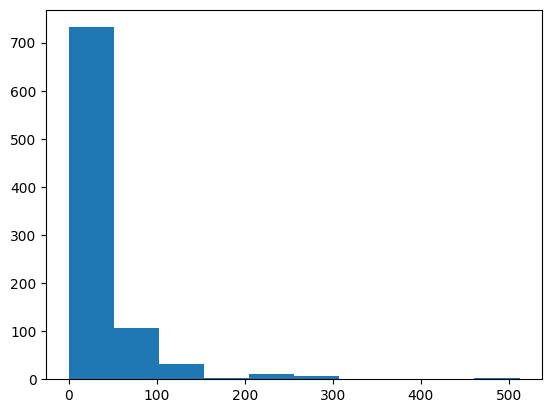

In [11]:
plt.hist(df['Fare'])
plt.show()

C:\Users\Garv\AppData\Local\Temp\ipykernel_13140\4162273133.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


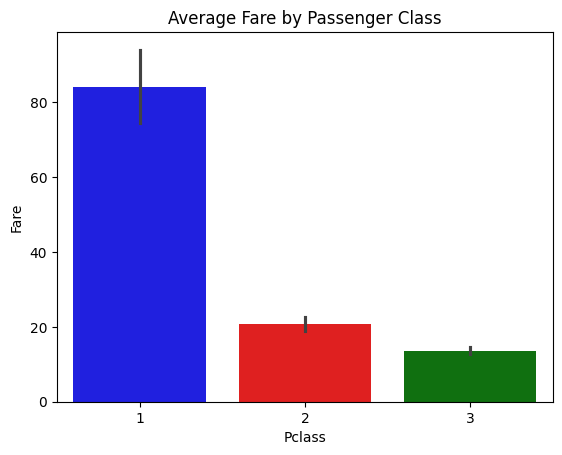

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [37]:
sns.barplot(
    data=df,
    x='Pclass',
    y='Fare',
    estimator='mean',
    palette=['blue', 'red', 'green']
)

plt.title('Average Fare by Passenger Class')
plt.show()
avg_fare = df.groupby('Pclass')['Fare'].mean()
print(avg_fare)

### 2. Distplot

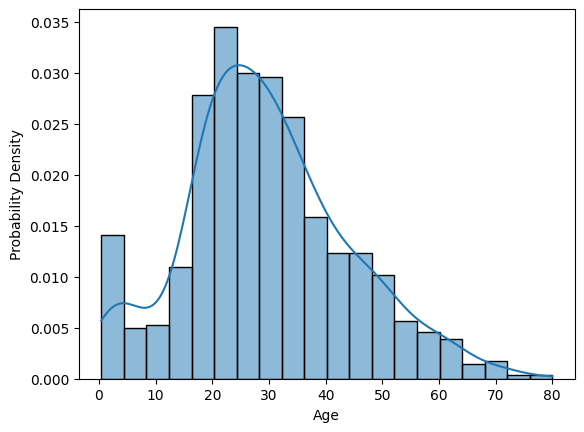

In [13]:
# sns.displot(data=df, x='Age',kde=True)
# sns.kdeplot(data=df, x='Age')
sns.histplot(
    data=df,
    x='Age',
    kde=True,
    stat='density'
)

plt.ylabel('Probability Density')
plt.show()
# KDE (density curve)
plt.show()

In [14]:
df['Age'].skew()

np.float64(0.38910778230082704)

### 3. Boxplot

<Axes: ylabel='Fare'>

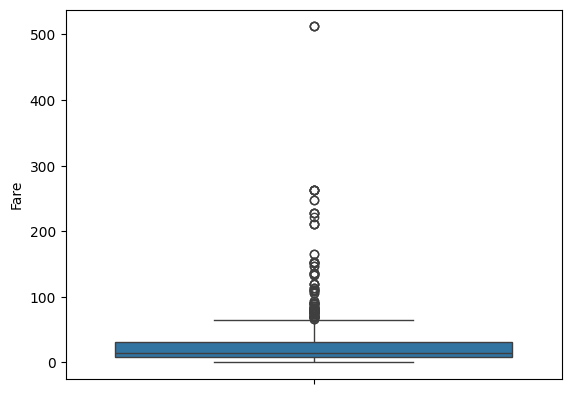

In [15]:
sns.boxplot(df['Fare'])